# Belousov-Zhabotinsky reaction

Use the Brusselator as a compact BZ-type oscillator with two tracked species, $X$ and $Y$:

$$\dot x = \alpha - x + \gamma x^2 y - \beta x,\qquad \dot y = \beta x - \gamma x^2 y.$$

With `chi = 0` and `omit_solvent_flux=True`, the solver reduces to Fickian reaction-diffusion for bulk oscillations, target waves, and spiral waves.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from jax_phase_separation.utils import build_params
from jax_phase_separation.solver import simulate, simulate_with_snapshots
from jax_phase_separation.reactions import build_reaction_system, empty_reaction_system

print('JAX version:', jax.__version__, '  devices:', jax.devices())

JAX version: 0.6.0   devices: [CpuDevice(id=0)]


In [2]:
def brusselator_reactions(alpha: float, beta: float, gamma: float, kscale: float = 1.0):
    """Build the Brusselator reaction network.

    Species: X (index 0, activator), Y (index 1, inhibitor).
    Chemostatted reservoirs A, B, D are absorbed into rate constants.

    ``kscale`` multiplies every rate constant. The dimensionless combinations
    alpha, beta, gamma (and hence the Hopf threshold, fixed point, and phase
    portrait) are invariant under this rescaling -- it only compresses time,
    which is useful for spatial runs where we want many wavelengths to fit in
    the periodic box (see notes below).
    """
    rxns = [
        # chemostat-driven production: . -> X, rate = alpha
        {'reactants': {},           'products': {0: 1}, 'k_plus': kscale * alpha},
        # linear decay: X -> .
        {'reactants': {0: 1},       'products': {},     'k_plus': kscale * 1.0},
        # conversion: X -> Y (represents B + X -> Y + D, B absorbed into beta)
        {'reactants': {0: 1},       'products': {1: 1}, 'k_plus': kscale * beta},
        # autocatalysis: 2X + Y -> 3X
        {'reactants': {0: 2, 1: 1}, 'products': {0: 3}, 'k_plus': kscale * gamma},
    ]
    return build_reaction_system(rxns, n_com=2)


def bz_limit_cycle_orbit(alpha, beta, gamma, kscale, *, dt=1e-5, n_steps=450_000, burn=160_000, n_phase=512):
    """Sample one Brusselator limit cycle, resampled uniformly in phase (for spiral ICs).

    The cos/sin winding used in many demos lies on a *circle* in (X, Y) space, but the
    real limit cycle is elongated — reactions immediately wipe that pattern. Here we
    trace the true orbit (same ODE as mass-action kinetics) and interpolate (X, Y)(φ).
    """
    x_star = alpha
    y_star = beta / (gamma * alpha)

    def step(u, _):
        x, y = u[0], u[1]
        dx = kscale * (alpha - (1.0 + beta) * x + gamma * x * x * y)
        dy = kscale * (beta * x - gamma * x * x * y)
        xn, yn = x + dt * dx, y + dt * dy
        un = jnp.stack([xn, yn])
        return un, un

    u0 = jnp.stack([x_star * 1.45, y_star * 0.82])
    _, traj = jax.lax.scan(step, u0, None, length=n_steps)
    trj = np.asarray(traj[int(burn) :])
    x1d = trj[:, 0]
    peaks = []
    for i in range(2, len(x1d) - 2):
        if x1d[i] > x1d[i - 1] and x1d[i] >= x1d[i + 1]:
            peaks.append(i)
        if len(peaks) >= 24:
            break
    if len(peaks) < 2:
        raise RuntimeError(
            'bz_limit_cycle_orbit: oscillation not detected — increase n_steps or reduce burn'
        )
    i0, i1 = peaks[-2], peaks[-1]
    seg = jnp.asarray(trj[i0:i1])
    m = int(seg.shape[0])
    base = jnp.linspace(0.0, 2 * jnp.pi, m, endpoint=False)
    ph = jnp.linspace(0.0, 2 * jnp.pi, n_phase, endpoint=False)
    b_ext = jnp.concatenate([base - 2 * jnp.pi, base, base + 2 * jnp.pi])
    x_ext = jnp.concatenate([seg[:, 0], seg[:, 0], seg[:, 0]])
    y_ext = jnp.concatenate([seg[:, 1], seg[:, 1], seg[:, 1]])
    x_cyc = jnp.interp(ph, b_ext, x_ext)
    y_cyc = jnp.interp(ph, b_ext, y_ext)
    return ph, x_cyc, y_cyc


# XLA warmup on a tiny grid so the first real run is fast.
_rxn = empty_reaction_system(2)
_chi = jnp.zeros((2, 2))
_p = build_params(_chi, 2, beta=0.2, lmbda=0.0, dt=1e-4, reactions=_rxn)
_c0 = 0.05 * jnp.ones((2, 16, 16))
_ = simulate(_c0, _p, 16, 10, rate_law='mass_action').block_until_ready()
print('warmup done')

warmup done


## 1. Bulk oscillations

Run a uniform 4x4 grid to check that the reaction source reproduces the well-mixed Brusselator limit cycle.

In [3]:
ALPHA = 0.02
BETA = 2.0
GAMMA = 500.0
beta_hopf = 1.0 + GAMMA * ALPHA ** 2
x_star = ALPHA
y_star = BETA / (GAMMA * ALPHA)
print(f'fixed point   (x*, y*) = ({x_star:.3f}, {y_star:.3f})')
print(f'Hopf threshold beta_H = 1 + gamma*alpha^2 = {beta_hopf:.3f}')
print(f'using beta = {BETA} ({"oscillatory" if BETA > beta_hopf else "stable focus"})')

N_COM = 2
N_BULK = 4
DT_BULK = 2e-4
N_STEPS_BULK = 180_000
SAVE_EVERY_BULK = 200

rxn_osc = brusselator_reactions(ALPHA, BETA, GAMMA)
chi0 = jnp.zeros((N_COM, N_COM))
params_bulk = build_params(chi0, N_COM, beta=0.2, lmbda=0.0, dt=DT_BULK, reactions=rxn_osc)

# uniform initial condition, slightly off the fixed point
c0_bulk = jnp.broadcast_to(
    jnp.array([x_star * 1.5, y_star * 0.7]).reshape(-1, 1, 1),
    (N_COM, N_BULK, N_BULK),
)
cf_bulk, snaps_bulk = simulate_with_snapshots(
    c0_bulk, params_bulk, N_BULK, N_STEPS_BULK,
    save_every=SAVE_EVERY_BULK, rate_law='mass_action',
)
print('finite?', bool(jnp.all(jnp.isfinite(cf_bulk))))

fixed point   (x*, y*) = (0.020, 0.200)
Hopf threshold beta_H = 1 + gamma*alpha^2 = 1.200
using beta = 2.0 (oscillatory)
finite? True


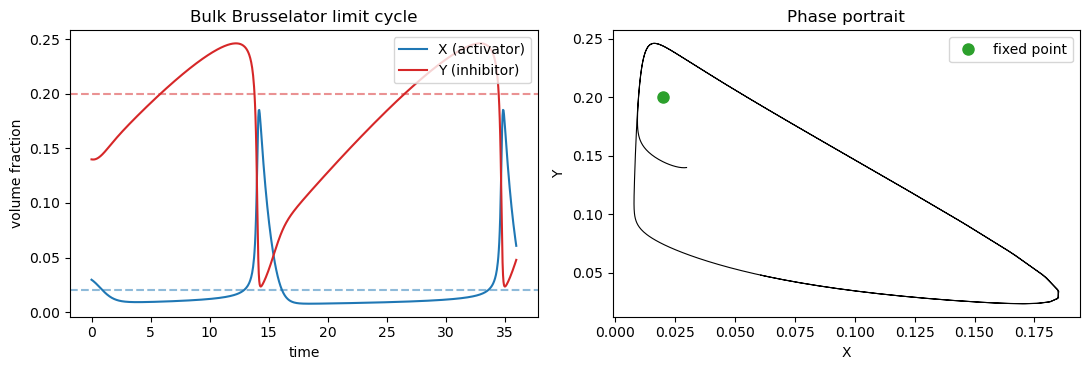

In [4]:
xt = snaps_bulk[:, 0].mean(axis=(-1, -2))
yt = snaps_bulk[:, 1].mean(axis=(-1, -2))
t = np.arange(len(xt)) * DT_BULK * SAVE_EVERY_BULK

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
ax.plot(t, xt, color='C0', label='X (activator)')
ax.plot(t, yt, color='C3', label='Y (inhibitor)')
ax.axhline(x_star, ls='--', color='C0', alpha=0.5)
ax.axhline(y_star, ls='--', color='C3', alpha=0.5)
ax.set_xlabel('time'); ax.set_ylabel('volume fraction')
ax.set_title('Bulk Brusselator limit cycle')
ax.legend(loc='upper right')

ax = axes[1]
ax.plot(xt, yt, color='k', lw=0.8)
ax.plot(x_star, y_star, 'o', color='C2', ms=8, label='fixed point')
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.set_title('Phase portrait')
ax.legend()
fig.tight_layout(); plt.show()

/var/folders/2j/mpwr7fpd6_s_yfpf7qxwjklr0000gn/T/ipykernel_13592/1812435715.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


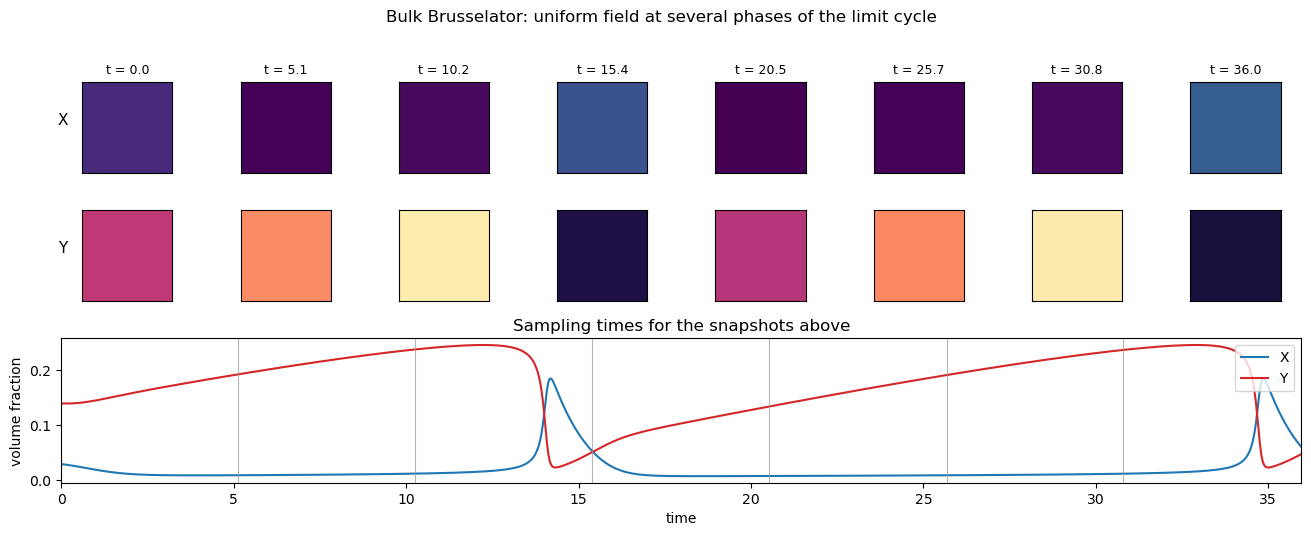

In [5]:
n_panels = 8
idx = np.linspace(0, len(snaps_bulk) - 1, n_panels).astype(int)
t_panels = t[idx]
snaps_bulk_np = np.asarray(snaps_bulk)

vmin_x, vmax_x = float(snaps_bulk_np[:, 0].min()), float(snaps_bulk_np[:, 0].max())
vmin_y, vmax_y = float(snaps_bulk_np[:, 1].min()), float(snaps_bulk_np[:, 1].max())

fig = plt.figure(figsize=(2.0 * n_panels, 5.2))
gs = fig.add_gridspec(3, n_panels, height_ratios=[1.0, 1.0, 1.6], hspace=0.35)

for j, i in enumerate(idx):
    ax = fig.add_subplot(gs[0, j])
    ax.imshow(snaps_bulk_np[i, 0], cmap='viridis', vmin=vmin_x, vmax=vmax_x, origin='lower')
    ax.set_title(f't = {t_panels[j]:.1f}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    if j == 0:
        ax.set_ylabel('X', rotation=0, labelpad=14, fontsize=11)

    ax = fig.add_subplot(gs[1, j])
    ax.imshow(snaps_bulk_np[i, 1], cmap='magma', vmin=vmin_y, vmax=vmax_y, origin='lower')
    ax.set_xticks([]); ax.set_yticks([])
    if j == 0:
        ax.set_ylabel('Y', rotation=0, labelpad=14, fontsize=11)

ax_trace = fig.add_subplot(gs[2, :])
ax_trace.plot(t, xt, color='C0', label='X')
ax_trace.plot(t, yt, color='C3', label='Y')
for tp in t_panels:
    ax_trace.axvline(tp, color='0.6', lw=0.8, alpha=0.7)
ax_trace.set_xlabel('time'); ax_trace.set_ylabel('volume fraction')
ax_trace.set_xlim(t[0], t[-1])
ax_trace.legend(loc='upper right')
ax_trace.set_title('Sampling times for the snapshots above')

fig.suptitle('Bulk Brusselator: uniform field at several phases of the limit cycle', y=1.02)
fig.tight_layout()
plt.show()

In [6]:
from matplotlib.animation import FuncAnimation

def make_bulk_movie(snaps, t, x_star, y_star, path='bz_bulk.mp4', fps=25, stride=1):
    """Animate the bulk Brusselator: X field, time traces, and phase portrait."""
    snaps = np.asarray(snaps)[::stride]
    t = np.asarray(t)[::stride]
    xt = snaps[:, 0].mean(axis=(-1, -2))
    yt = snaps[:, 1].mean(axis=(-1, -2))

    fig = plt.figure(figsize=(10, 4.2))
    gs = fig.add_gridspec(1, 3, width_ratios=[0.9, 1.4, 1.0], wspace=0.35)
    ax_im = fig.add_subplot(gs[0])
    ax_tr = fig.add_subplot(gs[1])
    ax_pp = fig.add_subplot(gs[2])

    vmin_x, vmax_x = float(snaps[:, 0].min()), float(snaps[:, 0].max())
    im = ax_im.imshow(snaps[0, 0], cmap='viridis', origin='lower',
                      vmin=vmin_x, vmax=vmax_x)
    ax_im.set_xticks([]); ax_im.set_yticks([])
    ax_im.set_title('X (activator)')

    ax_tr.plot(t, xt, color='C0', lw=0.8, alpha=0.25)
    ax_tr.plot(t, yt, color='C3', lw=0.8, alpha=0.25)
    (line_x,) = ax_tr.plot([], [], color='C0', lw=1.8, label='X')
    (line_y,) = ax_tr.plot([], [], color='C3', lw=1.8, label='Y')
    (dot_tr,) = ax_tr.plot([], [], 'ko', ms=4)
    ax_tr.set_xlim(t[0], t[-1])
    y_lo = min(xt.min(), yt.min()); y_hi = max(xt.max(), yt.max())
    ax_tr.set_ylim(y_lo - 0.02, y_hi + 0.02)
    ax_tr.set_xlabel('time'); ax_tr.set_ylabel('volume fraction')
    ax_tr.set_title('Time traces')
    ax_tr.legend(loc='upper right')

    ax_pp.plot(xt, yt, color='0.8', lw=0.8)
    ax_pp.plot(x_star, y_star, 'o', color='C2', ms=6, label='fixed point')
    (orbit,) = ax_pp.plot([], [], color='k', lw=1.2)
    (dot_pp,) = ax_pp.plot([], [], 'o', color='C1', ms=6)
    ax_pp.set_xlabel('X'); ax_pp.set_ylabel('Y')
    ax_pp.set_title('Phase portrait')
    ax_pp.legend(loc='lower right')

    def update(i):
        im.set_data(snaps[i, 0])
        line_x.set_data(t[: i + 1], xt[: i + 1])
        line_y.set_data(t[: i + 1], yt[: i + 1])
        dot_tr.set_data([t[i]], [xt[i]])
        orbit.set_data(xt[: i + 1], yt[: i + 1])
        dot_pp.set_data([xt[i]], [yt[i]])
        return im, line_x, line_y, dot_tr, orbit, dot_pp

    anim = FuncAnimation(fig, update, frames=len(snaps),
                         interval=1000 / fps, blit=True)
    anim.save(path, writer='ffmpeg', fps=fps, dpi=110)
    plt.close(fig)
    print(f'saved {path}  ({len(snaps)} frames)')

make_bulk_movie(snaps_bulk, t, x_star, y_star, path='bz_bulk.mp4', fps=25, stride=2)

saved bz_bulk.mp4  (450 frames)


## 2. Target waves

Use weaker diffusion, `omit_solvent_flux=True`, and a rescaled reaction rate so several wavelengths fit in the periodic box. A local perturbation seeds target rings.

In [7]:
N_GRID = 96
R_MU_BASE = 55.0   # larger => weaker diffusion overall; tune if rings are too fast/slow
# D_X = 1/(2 R_MU_BASE), D_Y = 1/R_MU_BASE  =>  D_Y / D_X = 2 (typical for Brusselator waves)
R_VEC_RD = jnp.array([[2.0 * R_MU_BASE], [R_MU_BASE]])
KSCALE = 15.0
DT = 4e-6
N_STEPS = 320_000    # total time ~ 1.28
SAVE_EVERY = 4000

rxn_osc_fast = brusselator_reactions(ALPHA, BETA, GAMMA, kscale=KSCALE)
params_spatial = build_params(
    chi0, N_COM, beta=0.2, lmbda=0.0, dt=DT, r_mu=R_VEC_RD, reactions=rxn_osc_fast,
    omit_solvent_flux=True,
)

c_uniform = jnp.ones((N_COM, N_GRID, N_GRID)) * jnp.array([x_star, y_star]).reshape(-1, 1, 1)
yy, xx = jnp.mgrid[:N_GRID, :N_GRID]
cx, cy = N_GRID // 2, N_GRID // 2
r2 = (xx - cx) ** 2 + (yy - cy) ** 2
bump = jnp.exp(-r2 / (2 * 4.0 ** 2)) * 0.22
c0_target = c_uniform.at[0].set(c_uniform[0] + bump)
k_noise = jax.random.PRNGKey(0)
c0_target = c0_target + 1e-3 * jax.random.normal(k_noise, c0_target.shape)

cf_target, snaps_target = simulate_with_snapshots(
    c0_target, params_spatial, N_GRID, N_STEPS,
    save_every=SAVE_EVERY, rate_law='mass_action',
)
print('snapshots:', snaps_target.shape)
print('X range:', float(snaps_target[:, 0].min()), float(snaps_target[:, 0].max()))
print('Y range:', float(snaps_target[:, 1].min()), float(snaps_target[:, 1].max()))

snapshots: (80, 2, 96, 96)
X range: 0.007840375415980816 0.325219064950943
Y range: 0.012145090848207474 0.24604322016239166


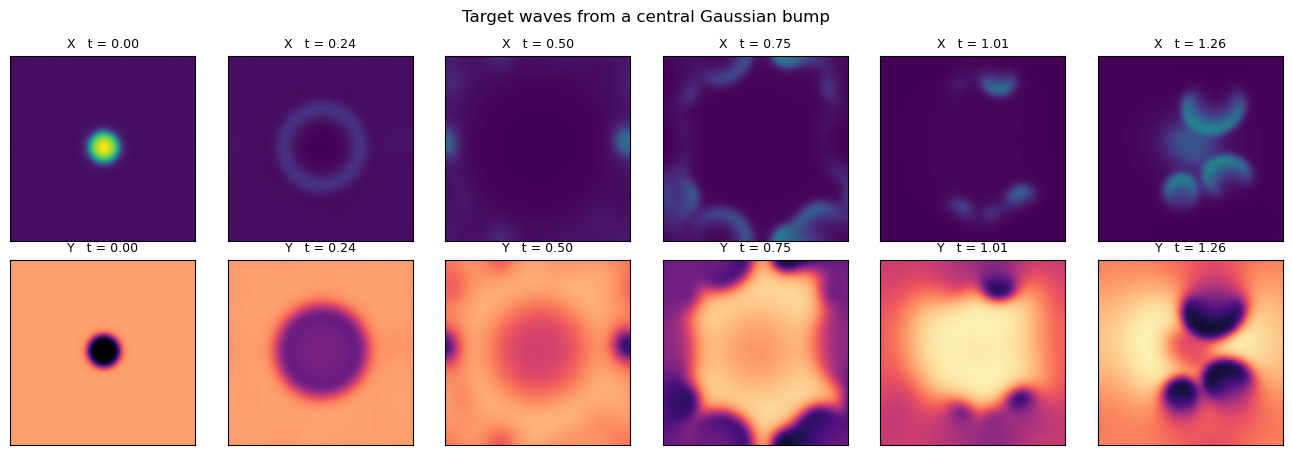

In [8]:
def plot_snapshots(snaps, title, n_cols=6, save_every=SAVE_EVERY, dt=DT):
    idx = np.linspace(0, len(snaps) - 1, n_cols).astype(int)
    fig, axes = plt.subplots(2, n_cols, figsize=(2.2 * n_cols, 4.6))
    vmin_x, vmax_x = float(snaps[:, 0].min()), float(snaps[:, 0].max())
    vmin_y, vmax_y = float(snaps[:, 1].min()), float(snaps[:, 1].max())
    for j, i in enumerate(idx):
        axes[0, j].imshow(snaps[i, 0], cmap='viridis', origin='lower',
                          vmin=vmin_x, vmax=vmax_x)
        axes[0, j].set_title(f'X   t = {i * save_every * dt:.2f}', fontsize=9)
        axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
        axes[1, j].imshow(snaps[i, 1], cmap='magma', origin='lower',
                          vmin=vmin_y, vmax=vmax_y)
        axes[1, j].set_title(f'Y   t = {i * save_every * dt:.2f}', fontsize=9)
        axes[1, j].set_xticks([]); axes[1, j].set_yticks([])
    fig.suptitle(title)
    fig.tight_layout()
    return fig

fig = plot_snapshots(np.asarray(snaps_target), 'Target waves from a central Gaussian bump')
plt.show()

In [12]:
from matplotlib.animation import FuncAnimation


def make_target_movie(snaps, path='bz_target.mp4', fps=15, save_every=SAVE_EVERY, dt=DT, stride=1):
    """Animate target / traveling waves: X and Y fields side by side."""
    snaps_full = np.asarray(snaps)
    snaps = snaps_full[::stride]
    frame_times = np.arange(0, len(snaps_full), stride)[: len(snaps)] * save_every * dt

    vmin_x, vmax_x = float(snaps_full[:, 0].min()), float(snaps_full[:, 0].max())
    vmin_y, vmax_y = float(snaps_full[:, 1].min()), float(snaps_full[:, 1].max())

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4.5))
    im0 = ax0.imshow(snaps[0, 0], cmap='viridis', origin='lower', vmin=vmin_x, vmax=vmax_x)
    im1 = ax1.imshow(snaps[0, 1], cmap='magma', origin='lower', vmin=vmin_y, vmax=vmax_y)
    for ax in (ax0, ax1):
        ax.set_xticks([])
        ax.set_yticks([])
    ax0.set_title('X (activator)')
    ax1.set_title('Y (inhibitor)')

    def update(i):
        im0.set_data(snaps[i, 0])
        im1.set_data(snaps[i, 1])
        fig.suptitle(f't = {frame_times[i]:.2f}')
        return im0, im1

    anim = FuncAnimation(fig, update, frames=len(snaps), interval=1000 / fps, blit=False)
    anim.save(path, writer='ffmpeg', fps=fps, dpi=100)
    plt.close(fig)
    print(f'saved {path}  ({len(snaps)} frames)')


make_target_movie(snaps_target, path='bz_target.mp4', fps=15, stride=2)


saved bz_target.mp4  (40 frames)


## 3. Spiral waves

Seed a phase winding using points sampled from the well-mixed limit cycle, then ramp to the fixed point near the spiral core.

In [9]:
from jax_phase_separation.solver import SimulationParams

# Spiral run: higher resolution and smaller dt.
# Uses variables from earlier BZ cells.
R_MU_BASE = 55.0  # keep in sync with target-wave cell
R_VEC_RD = jnp.array([[2.0 * R_MU_BASE], [R_MU_BASE]])

N_SPIRAL = 96
DT_SPIRAL = 4e-6
N_STEPS_SPIRAL = 400_000
SAVE_EVERY_SPIRAL = 8_000

print('limit-cycle trace for spiral IC (first run may take ~30s CPU after JIT)…')
lc_ph, lc_x, lc_y = bz_limit_cycle_orbit(ALPHA, BETA, GAMMA, KSCALE)

# Build params manually to choose A directly.
A_STAB = 5e-4
kappa = jnp.eye(N_COM)
chi_s = jnp.zeros((N_COM, N_COM))
params_spiral = SimulationParams(
    chi=chi0, kappa=kappa, chi_s=chi_s, r=R_VEC_RD,
    lmbda=0.0, dt=DT_SPIRAL, kon=0.0, koff=0.0, A=A_STAB,
    B=None, reactions=rxn_osc_fast, omit_solvent_flux=True,
)

# Spiral IC: polar angle mapped to the true limit cycle.
yy, xx = jnp.mgrid[:N_SPIRAL, :N_SPIRAL].astype(jnp.float32)
cx, cy = N_SPIRAL / 2 - 0.5, N_SPIRAL / 2 - 0.5
dx, dy = xx - cx, yy - cy
r_pix = jnp.sqrt(dx ** 2 + dy ** 2)
theta = jnp.arctan2(dy, dx)
phi_w = jnp.mod(theta + 2 * jnp.pi, 2 * jnp.pi)
core_radius = 5.0
ramp = jnp.tanh(r_pix / core_radius)
b_ext = jnp.concatenate([lc_ph - 2 * jnp.pi, lc_ph, lc_ph + 2 * jnp.pi])
x_ext = jnp.concatenate([lc_x, lc_x, lc_x])
y_ext = jnp.concatenate([lc_y, lc_y, lc_y])
x_orb = jnp.interp(phi_w, b_ext, x_ext)
y_orb = jnp.interp(phi_w, b_ext, y_ext)
x_field = (1.0 - ramp) * x_star + ramp * x_orb
y_field = (1.0 - ramp) * y_star + ramp * y_orb
c0_spiral = jnp.stack([x_field, y_field], axis=0).astype(jnp.float32)
print('IC X range =', float(c0_spiral[0].min()), float(c0_spiral[0].max()))
print('IC Y range =', float(c0_spiral[1].min()), float(c0_spiral[1].max()))
print('IC sum max =', float((c0_spiral[0] + c0_spiral[1]).max()))

cf_spiral, snaps_spiral = simulate_with_snapshots(
    c0_spiral, params_spiral, N_SPIRAL, N_STEPS_SPIRAL,
    save_every=SAVE_EVERY_SPIRAL, rate_law='mass_action',
)
print('snapshots:', snaps_spiral.shape)
print('X range:', float(snaps_spiral[:, 0].min()), float(snaps_spiral[:, 0].max()))
print('finite?', not bool(np.isnan(np.asarray(snaps_spiral)).any()))

limit-cycle trace for spiral IC (first run may take ~30s CPU after JIT)…
IC X range = 0.007770969998091459 0.18391923606395721
IC Y range = 0.02351713553071022 0.2461027204990387
IC sum max = 0.26376432180404663
snapshots: (50, 2, 96, 96)
X range: 0.00777643546462059 0.1798093318939209
finite? True


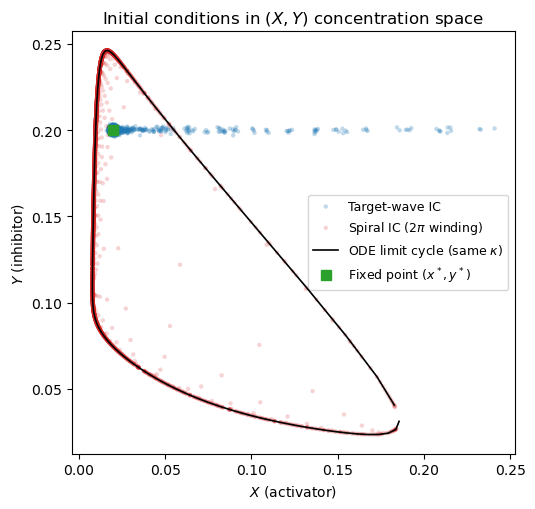

In [17]:
# Per-grid-point (X, Y) for each spatial IC, vs. the homogeneous ODE limit cycle (same kscale).
fig, ax = plt.subplots(figsize=(6.2, 5.2))

lc_xn = np.asarray(lc_x)
lc_yn = np.asarray(lc_y)


def _subsample_ravel(field0, field1, max_pts=6000):
    x = np.asarray(field0).ravel()
    y = np.asarray(field1).ravel()
    n = x.size
    if n <= max_pts:
        return x, y
    step = int(np.ceil(n / max_pts))
    return x[::step], y[::step]


tx, ty = _subsample_ravel(c0_target[0], c0_target[1])
ax.scatter(tx, ty, s=10, c='C0', alpha=0.28, zorder=2, label='Target-wave IC', edgecolors='none')

sx, sy = _subsample_ravel(c0_spiral[0], c0_spiral[1])
ax.scatter(sx, sy, s=10, c='C3', alpha=0.2, zorder=3, label='Spiral IC ($2\pi$ winding)', edgecolors='none')

ax.plot(
    lc_xn, lc_yn, color='k', lw=1.2, zorder=10,
    label='ODE limit cycle (same $\kappa$)',
)

ax.plot(
    x_star, y_star, 's', color='C2', ms=7, zorder=4,
    label='Fixed point $(x^*, y^*)$',
)


ax.set_xlabel('$X$ (activator)')
ax.set_ylabel('$Y$ (inhibitor)')
ax.set_title('Initial conditions in $(X, Y)$ concentration space')
ax.legend(loc='best', fontsize=9)
ax.set_aspect('equal', adjustable='box')
fig.tight_layout()
plt.show()


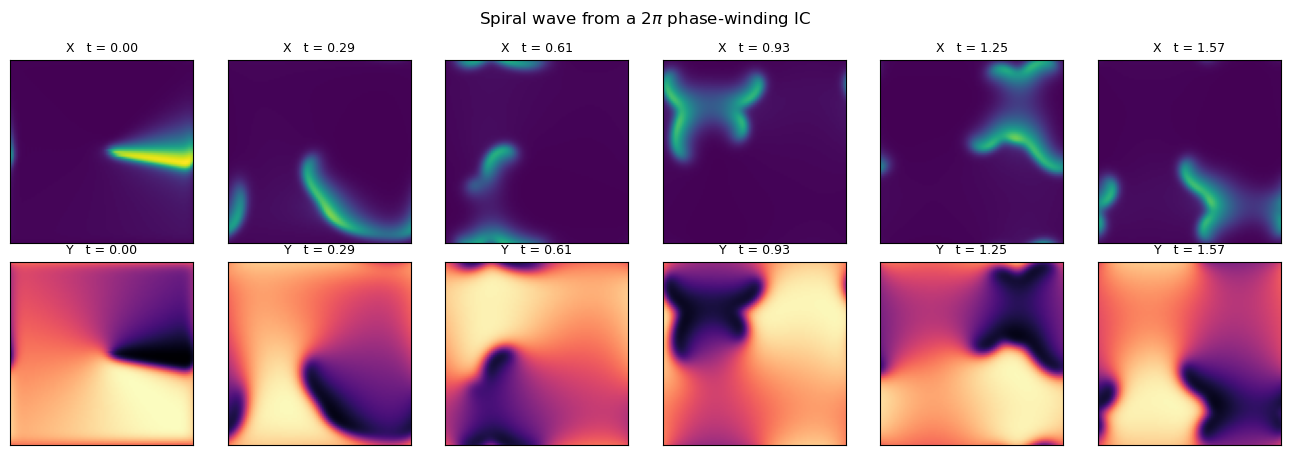

In [10]:
fig = plot_snapshots(np.asarray(snaps_spiral),
                     'Spiral wave from a $2\\pi$ phase-winding IC',
                     n_cols=6, save_every=SAVE_EVERY_SPIRAL, dt=DT_SPIRAL)
plt.show()

In [11]:
from matplotlib.animation import FuncAnimation

def make_spiral_movie(snaps, path='bz_spiral.mp4', fps=15):
    snaps = np.asarray(snaps)
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(snaps[0, 0], cmap='viridis', origin='lower',
                   vmin=float(snaps[:, 0].min()), vmax=float(snaps[:, 0].max()))
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title('X (activator)')

    def update(i):
        im.set_data(snaps[i, 0])
        ax.set_title(f'X   frame {i}/{len(snaps)-1}')
        return (im,)

    anim = FuncAnimation(fig, update, frames=len(snaps), interval=1000 / fps, blit=True)
    anim.save(path, writer='ffmpeg', fps=fps, dpi=100)
    plt.close(fig)
    print(f'saved {path}')

make_spiral_movie(snaps_spiral, path='bz_spiral.mp4', fps=15)

saved bz_spiral.mp4


In [18]:
from matplotlib.animation import FuncAnimation


def make_phase_space_movie(
    snaps,
    path,
    *,
    lc_x=None,
    lc_y=None,
    x_star=None,
    y_star=None,
    save_every=None,
    dt=None,
    stride=1,
    fps=12,
    dpi=100,
    point_color='C0',
):
    """Animate every grid point as a dot in local $(X, Y)$ space (one frame per snapshot)."""
    snaps_full = np.asarray(snaps)
    snaps = snaps_full[::stride]
    n_frames = snaps.shape[0]
    flat_x = snaps[:, 0].reshape(n_frames, -1)
    flat_y = snaps[:, 1].reshape(n_frames, -1)
    n_pts = flat_x.shape[1]

    x_lo, x_hi = float(flat_x.min()), float(flat_x.max())
    y_lo, y_hi = float(flat_y.min()), float(flat_y.max())
    pad = 0.06 * max(x_hi - x_lo, y_hi - y_lo, 1e-9)
    ax_xlim = (x_lo - pad, x_hi + pad)
    ax_ylim = (y_lo - pad, y_hi + pad)

    if save_every is not None and dt is not None:
        frame_times = np.arange(0, len(snaps_full), stride)[:n_frames] * save_every * dt
    else:
        frame_times = None

    fig, ax = plt.subplots(figsize=(6.2, 5.5))
    if lc_x is not None and lc_y is not None:
        ax.plot(np.asarray(lc_x), np.asarray(lc_y), color='0.82', lw=1.2, zorder=1)
    if x_star is not None and y_star is not None:
        ax.plot(x_star, y_star, 's', color='C2', ms=7, zorder=2)

    off0 = np.column_stack([flat_x[0], flat_y[0]])
    sc = ax.scatter(
        off0[:, 0], off0[:, 1], s=3, c=point_color, alpha=0.35,
        edgecolors='none', zorder=3,
    )
    ax.set_xlim(ax_xlim)
    ax.set_ylim(ax_ylim)
    ax.set_xlabel('$X$ (activator)')
    ax.set_ylabel('$Y$ (inhibitor)')
    ax.set_aspect('equal', adjustable='box')

    def update(i):
        sc.set_offsets(np.column_stack([flat_x[i], flat_y[i]]))
        if frame_times is not None:
            ax.set_title(f'All grid points in $(X,Y)$ space   $t = {frame_times[i]:.3f}$')
        else:
            ax.set_title(f'All grid points in $(X,Y)$ space   frame {i} / {n_frames - 1}')
        return (sc,)

    anim = FuncAnimation(fig, update, frames=n_frames, interval=1000 / fps, blit=False)
    anim.save(path, writer='ffmpeg', fps=fps, dpi=dpi)
    plt.close(fig)
    print(f'saved {path}  ({n_frames} frames, {n_pts} points/frame)')


# Needs `lc_x`, `lc_y` from the spiral cell (same kscale as spatial runs).
make_phase_space_movie(
    snaps_target,
    'bz_target_phase_space.mp4',
    lc_x=lc_x,
    lc_y=lc_y,
    x_star=x_star,
    y_star=y_star,
    save_every=SAVE_EVERY,
    dt=DT,
    stride=2,
    fps=12,
    point_color='C0',
)
make_phase_space_movie(
    snaps_spiral,
    'bz_spiral_phase_space.mp4',
    lc_x=lc_x,
    lc_y=lc_y,
    x_star=x_star,
    y_star=y_star,
    save_every=SAVE_EVERY_SPIRAL,
    dt=DT_SPIRAL,
    stride=1,
    fps=12,
    point_color='C3',
)


saved bz_target_phase_space.mp4  (40 frames, 9216 points/frame)
saved bz_spiral_phase_space.mp4  (50 frames, 9216 points/frame)
